# Computer Vision 
## Notebook 2a — BYOL Self-Supervised Pretraining on VisioDECT
| | |
|---|---|
| **Dataset** | **VisioDECT** (Part A cleaned image set, 20,603 images, labels **discarded** for SSL) |
| **SSL method** | **BYOL** — negative-free: an online network predicts an EMA **target network's** projection of a second augmented view |
| **Encoder** | Backbone of **YOLOv26-s** (Part A best), random init — the objective runs from scratch on our pool |
| **Framework** | `ssl-detection-lab` >= 0.8.1 (same `PretrainConfig` / distributed launcher as I-JEPA) |
| **Downstream pair** | Notebook 2b loads this checkpoint and fine-tunes at the 20% label budget |

**Covers steps in order:** CONFIG → environment → leakage-safe 10/10/80
partition (byte-identical to 3a/4a) → **two-view augmentation demo** (BYOL's method-specific
views) → model definition + dry-run → 30-epoch pretraining with the **loss curve and EMA
momentum schedule** → representation diagnostics → checkpoint export + hand-off.

## 0. How to Run This Notebook on Kaggle
1. **Create**: Kaggle → *Create* → *New Notebook* → File → Import Notebook.
2. **Settings**: Accelerator = **GPU T4 x2**; Internet = **On** (installs the course package
   from GitHub and downloads nothing else — pretraining starts from a randomly initialised
   YOLOv26-s backbone, as the assignment requires for I-JEPA).
3. **Attach the Part A Notebook 1 output**: *Add Input → Your Work →* the committed Part A
   **Notebook 1** → its Output. `visiodect_yolo/` must appear under `/kaggle/input/...`.
   Part B merges its three splits and **re-partitions 10/10/80 with the shared seed** — the
   Part A splits themselves are not reused.
4. **Version gate (course announcement)**: the install cell must print
   `ssl-detection-lab version: 0.8.1` **or newer**. If an older version appears:
   *Run → Restart & clear cell outputs*, then run all again from the top — the announcement
   documents this first-install quirk.
5. **Run all.** The §6 timing probe (1 epoch) prints a 30-epoch estimate — BYOL runs FOUR backbone passes per image pair (online + target on both views), the heaviest from-scratch method here, so respect the probe; proceed if it fits
   a single session; the documented fallback levers are in CONFIG.
6. **Commit** (*Save Version → Save & Run All*), set **Public**, then create a **public Kaggle
   dataset** from this notebook's output (e.g. `groupXX-partb-ssl-checkpoints`) — Notebook 3b
   attaches that dataset and loads `byol_backbone.pt` from it (§10 prints the exact files).

## 1. CONFIG
Everything §4.1 requires: method, encoder architecture, image size, batch size, epochs,
learning rate, the BYOL head/momentum parameters (its "masking-parameter" analogue is the
**view-augmentation + EMA schedule**), and the shared Part B seed.

In [ ]:
# =============================== CONFIG ===============================

# ---- method & encoder --------------------------------------------------
SSL_METHOD  = "byol"
YOLO_ARCH   = "yolo26s.yaml"   # ARCHITECTURE ONLY (random init): Part A best; same
                               # single-switch convention as Notebooks 3a/4a.
# Integration route (viva): like I-JEPA, the course package runs the BYOL
# objective DIRECTLY on the YOLO CNN backbone -- global-pooled backbone features
# feed the online projector/predictor -- so the pretrained weights load
# layer-for-layer into YOLOv26-s in Notebook 2b (same surgery as 3b/4b).

# ---- Part B shared partition protocol (IDENTICAL to 3a/4a) ---------------
PARTB_SEED   = 445
TEST_FRAC    = 0.10
VAL_FRAC     = 0.10

# ---- pretraining budget (assignment standard: 30 epochs) ----------------
FAST_RUN     = False
EPOCHS       = 50
IMAGE_SIZE   = 224
BATCH_SIZE   = 16     # per GPU. The tutorial uses 32 with yolo26n; yolo26s is
GRAD_ACCUM   = 2      # ~2x larger and BYOL makes 4 backbone passes per pair, so
                      # 16 x accum 2 keeps the same effective batch (64 on T4 x2)
                      # without OOM risk -- documented budget decision.
WORKERS      = 4
LR, MIN_LR   = 3e-4, 3e-6
WEIGHT_DECAY = 1e-4
WARMUP_EPOCHS = 2
GRAD_CLIP    = 5.0
AMP          = True   # fp16 autocast on the T4 (never bf16 -- Part A lesson)

# ---- BYOL heads & EMA schedule (tutorial full preset) --------------------
PROJECTION_DIM = 128  # online/target projector output width
HIDDEN_DIM     = 512  # hidden width of projector + predictor MLPs
EMA_MOMENTUM   = 0.996   # target = EMA(online); annealed to FINAL_MOMENTUM --
FINAL_MOMENTUM = 1.0     # the target ends frozen (viva: EMA + predictor
                         # asymmetry + stop-gradient is what prevents collapse
                         # WITHOUT negative pairs)

# ---- probe & paths -------------------------------------------------------
TIMING_PROBE = True
NB1_DIR_MANUAL = None
WORK_ROOT   = "/kaggle/working"
SSL_POOL_DIR = f"{WORK_ROOT}/ssl_pool"
OUTPUT_DIR   = f"{WORK_ROOT}/byol_yolo26s_visiodect"
PROBE_DIR    = f"{WORK_ROOT}/byol_probe"
PARTITION_CSV = f"{WORK_ROOT}/partB_partition.csv"
CKPT_BACKBONE = f"{WORK_ROOT}/byol_backbone.pt"          # §7 naming convention
CKPT_YOLO     = f"{WORK_ROOT}/byol_yolo26s_backbone.pt"  # what 2b's surgery loads

if FAST_RUN:
    EPOCHS, IMAGE_SIZE, BATCH_SIZE, GRAD_ACCUM = 2, 160, 8, 1
    PROJECTION_DIM, HIDDEN_DIM = 64, 128

print(f"CONFIG | {SSL_METHOD} on {YOLO_ARCH} | {EPOCHS} epochs @ {IMAGE_SIZE}px "
      f"| batch {BATCH_SIZE}x{GRAD_ACCUM}/GPU | proj {PROJECTION_DIM} hidden {HIDDEN_DIM} "
      f"| seed {PARTB_SEED}\ncheckpoint -> {CKPT_BACKBONE}")


CONFIG | byol on yolo26s.yaml | 50 epochs @ 224px | batch 16x2/GPU | proj 128 hidden 512 | seed 445
checkpoint -> /kaggle/working/byol_backbone.pt


## 2. Environment — install the course package and gate the version
Per the course announcement: rerun this cell after any restart and confirm it prints
**version 0.8.1 or newer**; if an older version appears, restart the session and rerun from
the top.

In [2]:
%pip install -q --no-cache-dir --force-reinstall --no-deps "git+https://github.com/rifat963/ssl-detection-lab.git@main" ultralytics


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 35.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
from pathlib import Path
from dataclasses import replace
from importlib.metadata import version as installed_version
import json, random, shutil, time, os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns
import torch
import torch.nn.functional as F
from PIL import Image
from packaging.version import Version
from sklearn.manifold import TSNE
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import v2
from tqdm.auto import tqdm
from ultralytics import YOLO

_v = installed_version("ssl-detection-lab")
print(f"ssl-detection-lab version: {_v}")
assert Version(_v) >= Version("0.8.1"), (
    "Older ssl-detection-lab detected. Per the course announcement: restart the "
    "session (Run -> Restart & clear cell outputs) and rerun the install cell first.")

import ssldet
from ssldet import PretrainConfig, launch_distributed_pretrain
from ssldet.backbones import YOLOBackboneEncoder
from ssldet.data import IMAGENET_MEAN, IMAGENET_STD, UnlabeledImageDataset, build_transform
from ssldet.ssl import create_ssl_module

random.seed(PARTB_SEED); np.random.seed(PARTB_SEED)
torch.manual_seed(PARTB_SEED); torch.cuda.manual_seed_all(PARTB_SEED)
torch.set_float32_matmul_precision("high")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

GPU_COUNT = max(1, torch.cuda.device_count())
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(pd.Series({"ssl-detection-lab": ssldet.__version__, "PyTorch": torch.__version__,
                 "GPUs": GPU_COUNT if torch.cuda.is_available() else "CPU (smoke only)"}))


Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
ssl-detection-lab version: 0.9.0
ssl-detection-lab           0.9.0
PyTorch              2.10.0+cu128
GPUs                            2
dtype: object


## 3. Leakage-Safe 10/10/80 Partition (shared by every SSL notebook)
The Part A splits are **not reused**: all 20,603 cleaned images are merged and re-partitioned
once, at image level, with the shared seed — 10% test holdout, 10% validation, 80% SSL pool.
This cell **prints the partition sizes** and **verifies by filename intersection** that test
and validation are disjoint from the SSL pool (both are assignment mandates). It also assigns
every pool image a seeded `pool_rank`, so the 20% fine-tuning subset (Notebook 3b) and the
bonus 10–50% budgets are **nested by construction** — budget ρ is simply
`pool_rank < ρ·|D|`. The manifest is exported for hand-off so every notebook provably uses
the identical partition.

**Why this is not leakage :** SSL pretraining never reads annotations, so no label
information can leak; fine-tuning images legitimately overlap the SSL pool (the standard
SimCLR/BYOL label-efficiency protocol); leakage would require test/val pixels in the pool,
labels influencing pretraining, or test-driven tuning — the checks below rule out the first
and the pipeline never does the other two.

**Consistency note:** verbatim from Notebooks 3a/4a — same seed, same algorithm — so the exported manifest is byte-identical and diffable as proof.

In [4]:
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def find_nb1_root():
    if NB1_DIR_MANUAL is not None:
        p = Path(NB1_DIR_MANUAL)
        if (p / "train" / "images").exists():
            return p
        raise FileNotFoundError(f"Manual path is not the NB1 output: {p}")
    base, stack = Path("/kaggle/input"), []
    stack.append((base, 0))
    while stack:
        d, dep = stack.pop()
        if d.name == "visiodect_yolo" and (d / "train" / "images").exists():
            return d
        if dep < 4:
            try:
                stack += [(c, dep + 1) for c in d.iterdir() if c.is_dir()]
            except (PermissionError, OSError):
                pass
    raise FileNotFoundError("Attach Part A Notebook 1's OUTPUT (visiodect_yolo/) as input.")

NB1_ROOT = find_nb1_root()
all_images = sorted(p for s in ("train", "val", "test")
                    for p in (NB1_ROOT / s / "images").rglob("*")
                    if p.is_file() and p.suffix.lower() in IMG_EXTS)
N = len(all_images)
print(f"NB1 root: {NB1_ROOT}\nMerged Part A images: {N:,}")

# ---- one seeded shuffle drives everything -----------------------------------
names = [p.name for p in all_images]
assert len(set(names)) == N, "filename collision across NB1 splits!"
order = list(range(N))
random.Random(PARTB_SEED).shuffle(order)
n_test, n_val = round(TEST_FRAC * N), round(VAL_FRAC * N)
test_idx = set(order[:n_test])
val_idx  = set(order[n_test:n_test + n_val])
pool_pos = order[n_test + n_val:]                 # shuffled order -> nested budgets

rows, pool_rank = [], {i: r for r, i in enumerate(pool_pos)}
for i, p in enumerate(all_images):
    part = "test" if i in test_idx else "val" if i in val_idx else "ssl_pool"
    rows.append({"filename": p.name, "source_path": str(p), "partition": part,
                 "pool_rank": pool_rank.get(i, -1)})
partition = pd.DataFrame(rows)
partition.to_csv(PARTITION_CSV, index=False)

sizes = partition.partition.value_counts()
print(f"\nPartition sizes (seed {PARTB_SEED}):")
print(sizes.to_string())
print(f"20% fine-tune budget for 3b = pool_rank < {round(0.20 * N):,} "
      f"(nested; bonus budgets use the same ranks)")

# ---- mandated disjointness verification (filename intersections) ------------
sets = {k: set(partition[partition.partition == k].filename)
        for k in ("test", "val", "ssl_pool")}
assert not (sets["test"] & sets["ssl_pool"]), "TEST leaked into SSL pool!"
assert not (sets["val"]  & sets["ssl_pool"]), "VAL leaked into SSL pool!"
assert not (sets["test"] & sets["val"]),      "TEST/VAL overlap!"
assert sum(map(len, sets.values())) == N
print("\n[OK] Disjointness verified by filename intersection: "
      "test ∩ pool = 0, val ∩ pool = 0, test ∩ val = 0")


NB1 root: /kaggle/input/notebooks/ahnafahmed11/cse445notebook1-datasetexploration-preprocessing/visiodect_yolo
Merged Part A images: 20,603

Partition sizes (seed 445):
partition
ssl_pool    16483
test         2060
val          2060
20% fine-tune budget for 3b = pool_rank < 4,121 (nested; bonus budgets use the same ranks)

[OK] Disjointness verified by filename intersection: test ∩ pool = 0, val ∩ pool = 0, test ∩ val = 0


In [5]:
# ---- materialise the SSL pool as a directory (labels never copied) ----------
pool_dir = Path(SSL_POOL_DIR)
if pool_dir.exists():
    shutil.rmtree(pool_dir)
pool_dir.mkdir(parents=True)
for _, r in tqdm(partition[partition.partition == "ssl_pool"].iterrows(),
                 total=len(sets["ssl_pool"]), desc="linking SSL pool"):
    dst = pool_dir / r.filename
    try:
        os.symlink(r.source_path, dst)
    except OSError:
        shutil.copy2(r.source_path, dst)

pool_images = sorted(p for p in pool_dir.iterdir() if p.suffix.lower() in IMG_EXTS)
assert len(pool_images) == len(sets["ssl_pool"])
print(f"SSL pool directory ready: {len(pool_images):,} images "
      "(image files only — no label file is ever read in this notebook)")


linking SSL pool:   0%|          | 0/16483 [00:00<?, ?it/s]

SSL pool directory ready: 16,483 images (image files only — no label file is ever read in this notebook)


## 4. Method-Specific Views — BYOL's Two Augmented Views 
Where I-JEPA's signal is **masking**, BYOL's signal is **augmentation invariance**: each
image is transformed twice (crop/flip/colour-jitter/blur), the **online network** sees one
view, the frozen-to-gradients **EMA target network** sees the other, and the online
predictor must regress the target's projection. `build_transform(config)` therefore returns
a *pair*; the grid below shows both views for three pool images — the assignment's
single-image view demo. No hand-crafted negatives exist anywhere (viva: what prevents
"predict a constant" collapse is the target being an EMA — it moves slower than the online
network can cheat — plus the predictor asymmetry and stop-gradient on the target branch).

In [6]:
ssl_config = PretrainConfig(
    method=SSL_METHOD,
    image_roots=[str(SSL_POOL_DIR)],          # the 80% pool ONLY (verified above)
    output_dir=str(OUTPUT_DIR),
    yolo_model=YOLO_ARCH,
    epochs=EPOCHS, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE,
    workers=WORKERS, max_images=None, seed=PARTB_SEED,
    learning_rate=LR, min_learning_rate=MIN_LR, weight_decay=WEIGHT_DECAY,
    warmup_epochs=WARMUP_EPOCHS, grad_accum_steps=GRAD_ACCUM,
    gradient_clip=GRAD_CLIP, amp=AMP,
    projection_dim=PROJECTION_DIM, hidden_dim=HIDDEN_DIM,
    momentum=EMA_MOMENTUM, final_momentum=FINAL_MOMENTUM,
    save_every=1,
).validate()
print("PretrainConfig validated | method:", ssl_config.method,
      f"| views per image: 2 (online + target) | effective batch: "
      f"{BATCH_SIZE * GRAD_ACCUM} per GPU")


PretrainConfig validated | method: byol | views per image: 2 (online + target) | effective batch: 32 per GPU


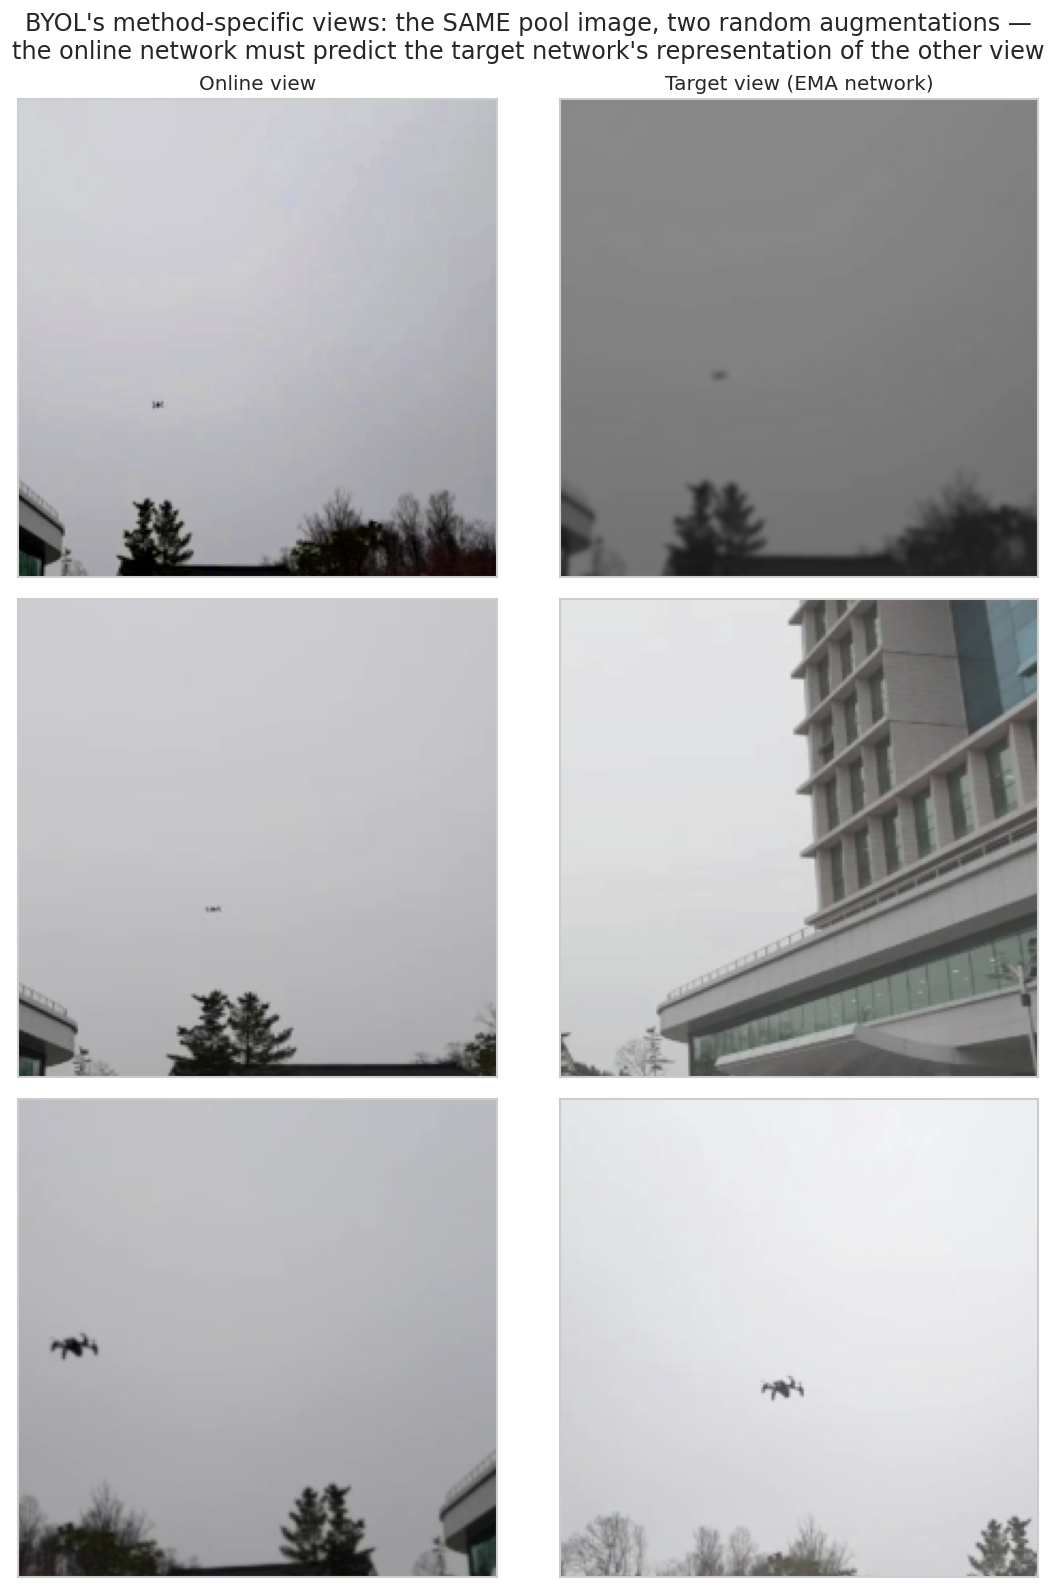

Augmentations are BYOL's entire learning signal (viva contrast: I-JEPA used NONE and relied on masking instead).


In [7]:
preview_dataset = UnlabeledImageDataset(pool_images, build_transform(ssl_config))
mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
show = lambda t: (t.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0)

fig, axes = plt.subplots(3, 2, figsize=(9.5, 13.5))
for row in range(3):
    view1, view2 = preview_dataset[row]
    axes[row, 0].imshow(show(view1)); axes[row, 1].imshow(show(view2))
    for ax in axes[row]:
        ax.set_xticks([]); ax.set_yticks([])
axes[0, 0].set_title("Online view"); axes[0, 1].set_title("Target view (EMA network)")
fig.suptitle("BYOL's method-specific views: the SAME pool image, two random augmentations —\n"
             "the online network must predict the target network's representation of the other view")
plt.tight_layout(); plt.show()
print("Augmentations are BYOL's entire learning signal (viva contrast: I-JEPA used NONE "
      "and relied on masking instead).")


## 5. Model Definition + Dry Run 
Online branch = YOLOv26-s backbone (random init) + projector + predictor; target branch =
EMA copies of encoder + projector, **frozen to gradients** (updated only by momentum). The
loss is the symmetrised **negative cosine similarity** between the online prediction and the
target projection. One forward pass prints the feature width and an untrained example loss.
Note the cost signature for the budget: **four backbone passes per image pair**.

In [8]:
probe_detector = YOLO(ssl_config.yolo_model)
probe_encoder  = YOLOBackboneEncoder(probe_detector.model).to(DEVICE)
with torch.inference_mode():
    feature_dim = probe_encoder(
        torch.zeros(1, 3, ssl_config.image_size, ssl_config.image_size, device=DEVICE)
    ).shape[1]

byol_module = create_ssl_module(
    SSL_METHOD, encoder=probe_encoder, feature_dim=feature_dim,
    hidden_dim=ssl_config.hidden_dim, projection_dim=ssl_config.projection_dim,
    momentum=ssl_config.momentum,
).to(DEVICE)

view1, view2 = preview_dataset[0]
amp_ctx = torch.amp.autocast("cuda") if DEVICE.type == "cuda" else torch.amp.autocast("cpu", enabled=False)
with torch.inference_mode(), amp_ctx:
    example_loss = byol_module((view1.unsqueeze(0).to(DEVICE),
                                view2.unsqueeze(0).to(DEVICE)))

print(pd.Series({
    "encoder": f"YOLOv26-s backbone ({sum(p.numel() for p in probe_encoder.parameters())/1e6:.1f} M params)",
    "feature dim -> projection dim": f"{feature_dim} -> {ssl_config.projection_dim}",
    "untrained example loss (neg-cosine)": round(float(example_loss), 4),
    "target encoder trainable": any(p.requires_grad
                                    for p in byol_module.target_encoder.parameters()),
    "backbone passes per image pair": 4,
}))
del byol_module, probe_encoder, probe_detector, view1, view2, example_loss
torch.cuda.empty_cache()


encoder                                YOLOv26-s backbone (5.4 M params)
feature dim -> projection dim                                 512 -> 128
untrained example loss (neg-cosine)                               2.2375
target encoder trainable                                           False
backbone passes per image pair                                         4
dtype: object


## 6. 1-Epoch Timing Probe 
BYOL's four backbone passes per pair make it the heaviest from-scratch method here, so this probe matters most. The assignment mandates the 50-epoch run fit one T4 session and allows documented budget
levers (resolution, AMP). This probe measures one real epoch through the launcher and
extrapolates ×30 — the same measure-before-commit protocol that saved Part A twice.

In [9]:
if TIMING_PROBE:
    probe_cfg = replace(ssl_config, epochs=1, warmup_epochs=0,
                        output_dir=str(PROBE_DIR)).validate()
    t0 = time.time()
    launch_distributed_pretrain(probe_cfg, num_processes=GPU_COUNT,
                                config_path=Path(PROBE_DIR) / "probe_config.yaml", check=True)
    probe_min = (time.time() - t0) / 60
    est = probe_min * EPOCHS
    print(f"\nProbe epoch: {probe_min:.1f} min -> {EPOCHS}-epoch estimate: "
          f"{est:.0f} min ({est/60:.1f} h)")
    print("[OK] Fits a single session." if est <= 9 * 60 else
          "[!] OVER BUDGET — documented levers, in order: IMAGE_SIZE 224 -> 192 "
          "(grid 6x6), BATCH_SIZE up if VRAM allows (fewer steps), then epochs "
          "reduction applied identically to ALL four SSL methods (assignment rule).")
    shutil.rmtree(PROBE_DIR, ignore_errors=True)
else:
    print("Timing probe skipped (TIMING_PROBE=False).")


BYOL 01/01: 100%|██████████| 515/515 [05:03<00:00,  1.70it/s, ema=1.00000, loss=0.0379, lr=3.01e-06]


Epoch 01 | loss=0.03779 | time=303.5s


/usr/local/lib/python3.12/dist-packages/torch/distributed/c10d_logger.py:83: UserWarning: barrier(): using the device under current context. You can specify `device_id` in `init_process_group` to mute this warning.
  return func(*args, **kwargs)


{
  "output_dir": "/kaggle/working/byol_probe",
  "yolo_checkpoint": "/kaggle/working/byol_probe/byol_pretrained_yolo26s.pt",
  "ssl_checkpoint": "/kaggle/working/byol_probe/last_ssl.pt",
  "history_csv": "/kaggle/working/byol_probe/history.csv",
  "manifest_json": "/kaggle/working/byol_probe/run_manifest.json"
}
{
  "output_dir": "/kaggle/working/byol_probe",
  "yolo_checkpoint": "/kaggle/working/byol_probe/byol_pretrained_yolo26s.pt",
  "ssl_checkpoint": "/kaggle/working/byol_probe/last_ssl.pt",
  "history_csv": "/kaggle/working/byol_probe/history.csv",
  "manifest_json": "/kaggle/working/byol_probe/run_manifest.json"
}

Probe epoch: 5.4 min -> 50-epoch estimate: 271 min (4.5 h)
[OK] Fits a single session.


## 7. Full Pretraining — 50 Epochs 
Both T4s via the distributed launcher; loss logged per epoch to `history.csv`; no label file
is ever opened.

In [10]:
t0 = time.time()
training_result = launch_distributed_pretrain(
    ssl_config, num_processes=GPU_COUNT,
    config_path=Path(OUTPUT_DIR) / "byol_config.yaml", check=True)
TRAIN_MINUTES = (time.time() - t0) / 60
print(f"\nPretraining wall time: {TRAIN_MINUTES:.1f} min")
print(training_result)


BYOL 01/50: 100%|██████████| 515/515 [05:08<00:00,  1.67it/s, ema=0.99600, loss=0.3732, lr=1.51e-04]


Epoch 01 | loss=0.37337 | time=308.8s


BYOL 02/50: 100%|██████████| 515/515 [04:58<00:00,  1.72it/s, ema=0.99602, loss=0.0650, lr=3.00e-04]


Epoch 02 | loss=0.06384 | time=298.7s


BYOL 03/50: 100%|██████████| 515/515 [05:04<00:00,  1.69it/s, ema=0.99604, loss=0.0242, lr=3.00e-04]


...

Epoch 49 | loss=0.02909 | time=298.7s


BYOL 50/50: 100%|██████████| 515/515 [05:03<00:00,  1.69it/s, ema=1.00000, loss=0.0299, lr=3.00e-06]


Epoch 50 | loss=0.02948 | time=303.9s


/usr/local/lib/python3.12/dist-packages/torch/distributed/c10d_logger.py:83: UserWarning: barrier(): using the device under current context. You can specify `device_id` in `init_process_group` to mute this warning.
  return func(*args, **kwargs)


{
  "output_dir": "/kaggle/working/byol_yolo26s_visiodect",
  "yolo_checkpoint": "/kaggle/working/byol_yolo26s_visiodect/byol_pretrained_yolo26s.pt",
  "ssl_checkpoint": "/kaggle/working/byol_yolo26s_visiodect/last_ssl.pt",
  "history_csv": "/kaggle/working/byol_yolo26s_visiodect/history.csv",
  "manifest_json": "/kaggle/working/byol_yolo26s_visiodect/run_manifest.json"
}
{
  "output_dir": "/kaggle/working/byol_yolo26s_visiodect",
  "yolo_checkpoint": "/kaggle/working/byol_yolo26s_visiodect/byol_pretrained_yolo26s.pt",
  "ssl_checkpoint": "/kaggle/working/byol_yolo26s_visiodect/last_ssl.pt",
  "history_csv": "/kaggle/working/byol_yolo26s_visiodect/history.csv",
  "manifest_json": "/kaggle/working/byol_yolo26s_visiodect/run_manifest.json"
}

Pretraining wall time: 250.6 min
DistributedPretrainResult(config_path=PosixPath('/kaggle/working/byol_yolo26s_visiodect/byol_config.yaml'), output_dir=PosixPath('/kaggle/working/byol_yolo26s_visiodect'), command=('/usr/bin/python3', '-m', 'torch.di

### 7.1 The BYOL Loss Curve — 
The plotted loss is the symmetrised negative-cosine regression between online predictions
and EMA-target projections. Expected shape: a **steady decrease** as the online network
aligns with the slowly moving target. Two readings matter for the viva: (1) a loss driving
toward its floor is *not* automatically collapse — collapse would ALSO show near-zero
feature spread, which §8 measures directly (per-dimension std) and refutes; (2) the EMA
momentum panel shows the target annealing 0.996 → 1.0, i.e. the target ends fully frozen.

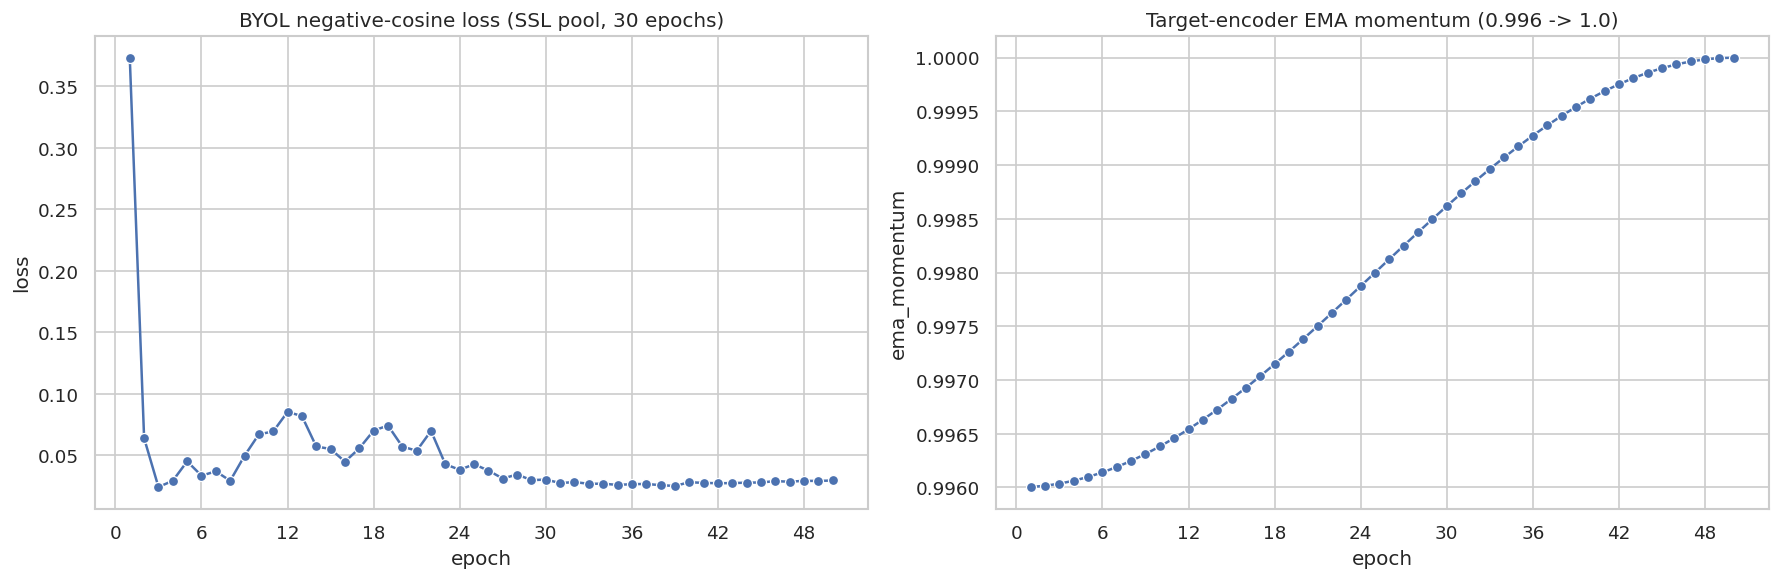

best SSL checkpoint                /kaggle/working/byol_yolo26s_visiodect/best_ss...
YOLO-format backbone checkpoint    /kaggle/working/byol_yolo26s_visiodect/byol_pr...
best loss                                                                   0.024138
unlabelled images seen                                                         16483
world size (GPUs)                                                                  2
dtype: object
[OK] trainer consumed exactly the verified 80% pool — nothing more, nothing less
loss trajectory: epoch 1 = 0.3734 -> epoch 50 = 0.0295 (92% reduction)


In [11]:
history  = pd.read_csv(Path(OUTPUT_DIR) / "history.csv")
manifest = json.loads((Path(OUTPUT_DIR) / "run_manifest.json").read_text())
BEST_SSL = Path(OUTPUT_DIR) / "best_ssl.pt"
YOLO_CHECKPOINT = Path(manifest["outputs"]["yolo_checkpoint"])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.lineplot(data=history, x="epoch", y="loss", marker="o", ax=axes[0])
axes[0].set_title("BYOL negative-cosine loss (SSL pool, 30 epochs)")
if "ema_momentum" in history:
    sns.lineplot(data=history, x="epoch", y="ema_momentum", marker="o", ax=axes[1])
    axes[1].set_title("Target-encoder EMA momentum (0.996 -> 1.0)")
for ax in axes:
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig(f"{WORK_ROOT}/byol_loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print(pd.Series({
    "best SSL checkpoint": str(BEST_SSL),
    "YOLO-format backbone checkpoint": str(YOLO_CHECKPOINT),
    "best loss": manifest["best_loss"],
    "unlabelled images seen": manifest["unlabeled_images"],
    "world size (GPUs)": manifest["world_size"],
}))
assert manifest["unlabeled_images"] == len(pool_images), \
    "trainer saw a different image count than the verified SSL pool!"
print("[OK] trainer consumed exactly the verified 80% pool — nothing more, nothing less")

print(f"loss trajectory: epoch 1 = {history.loss.iloc[0]:.4f} -> "
      f"epoch {int(history.epoch.iloc[-1])} = {history.loss.iloc[-1]:.4f} "
      f"({(1 - history.loss.iloc[-1]/max(history.loss.iloc[0],1e-9)):.0%} reduction)")


## 8. Representation Diagnostics 
Embeddings are extracted for a **500-image sample of the validation partition** (never seen
during pretraining) with the trained backbone. VisioDECT's filenames encode
`Class_scenario_original`, so the t-SNE can be coloured two ways — by **drone class** (does
the representation organise target-class content?) and by **scenario** (or does it organise
by lighting instead — an equally honest finding). The retrieval panels and a quantitative
top-5 neighbour class-agreement score back the visual impression. Scoreboard so far — I-JEPA: 95.0% class / 97.5% scenario; DINOv3 (domain-adaptive): 97.2% / 97.2%. Where augmentation-invariance training lands is this section's question — and the per-dimension feature std printed below is the direct anti-collapse evidence for the BYOL viva. Labels are used here for
**colouring diagnostics only, after training** — pretraining never saw them.

In [12]:
SCENARIOS = ["cloudy", "evening", "sunny"]
CLASS_NAMES = ["Anafi", "DJI_FPV", "DJI_Phantom", "EFT_E410S", "Mavic_Air", "Mavic_Enterprise"]

def parse_stem(stem):
    for c in sorted(CLASS_NAMES, key=len, reverse=True):
        if stem.startswith(c + "_"):
            rest = stem[len(c) + 1:]
            scen = rest.split("_")[0]
            return c, scen if scen in SCENARIOS else "unknown"
    return "unknown", "unknown"

val_rows = partition[partition.partition == "val"]
sel = val_rows.sample(min(500, len(val_rows)), random_state=PARTB_SEED)
sel_paths  = [Path(p) for p in sel.source_path]
sel_class  = [parse_stem(Path(p).stem)[0] for p in sel.source_path]
sel_scen   = [parse_stem(Path(p).stem)[1] for p in sel.source_path]

feature_transform = v2.Compose([
    v2.Resize(ssl_config.image_size + 32, antialias=True),
    v2.CenterCrop(ssl_config.image_size),
    v2.ToImage(), v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(IMAGENET_MEAN, IMAGENET_STD)])

class FeatureDataset(Dataset):
    def __len__(self):
        return len(sel_paths)
    def __getitem__(self, i):
        with Image.open(sel_paths[i]) as im:
            return feature_transform(im.convert("RGB")), i

encoder = YOLOBackboneEncoder(YOLO(str(YOLO_CHECKPOINT)).model).to(DEVICE).eval()
loader = DataLoader(FeatureDataset(), batch_size=64, shuffle=False,
                    num_workers=min(2, WORKERS), pin_memory=DEVICE.type == "cuda")
feats = []
amp_ctx = torch.amp.autocast("cuda") if DEVICE.type == "cuda" else torch.amp.autocast("cpu", enabled=False)
with torch.inference_mode(), amp_ctx:
    for images, _ in tqdm(loader, desc="extracting BYOL features (val sample)"):
        f = encoder(images.to(DEVICE, non_blocking=True))
        feats.append(F.normalize(f.float(), dim=1).cpu())
feature_matrix = torch.cat(feats)
print(f"features: {tuple(feature_matrix.shape)} | "
      f"mean per-dim std: {feature_matrix.std(dim=0).mean():.4f} "
      "(a healthy non-collapsed representation has clearly non-zero spread)")


extracting BYOL features (val sample):   0%|          | 0/8 [00:00<?, ?it/s]

features: (500, 512) | mean per-dim std: 0.0376 (a healthy non-collapsed representation has clearly non-zero spread)


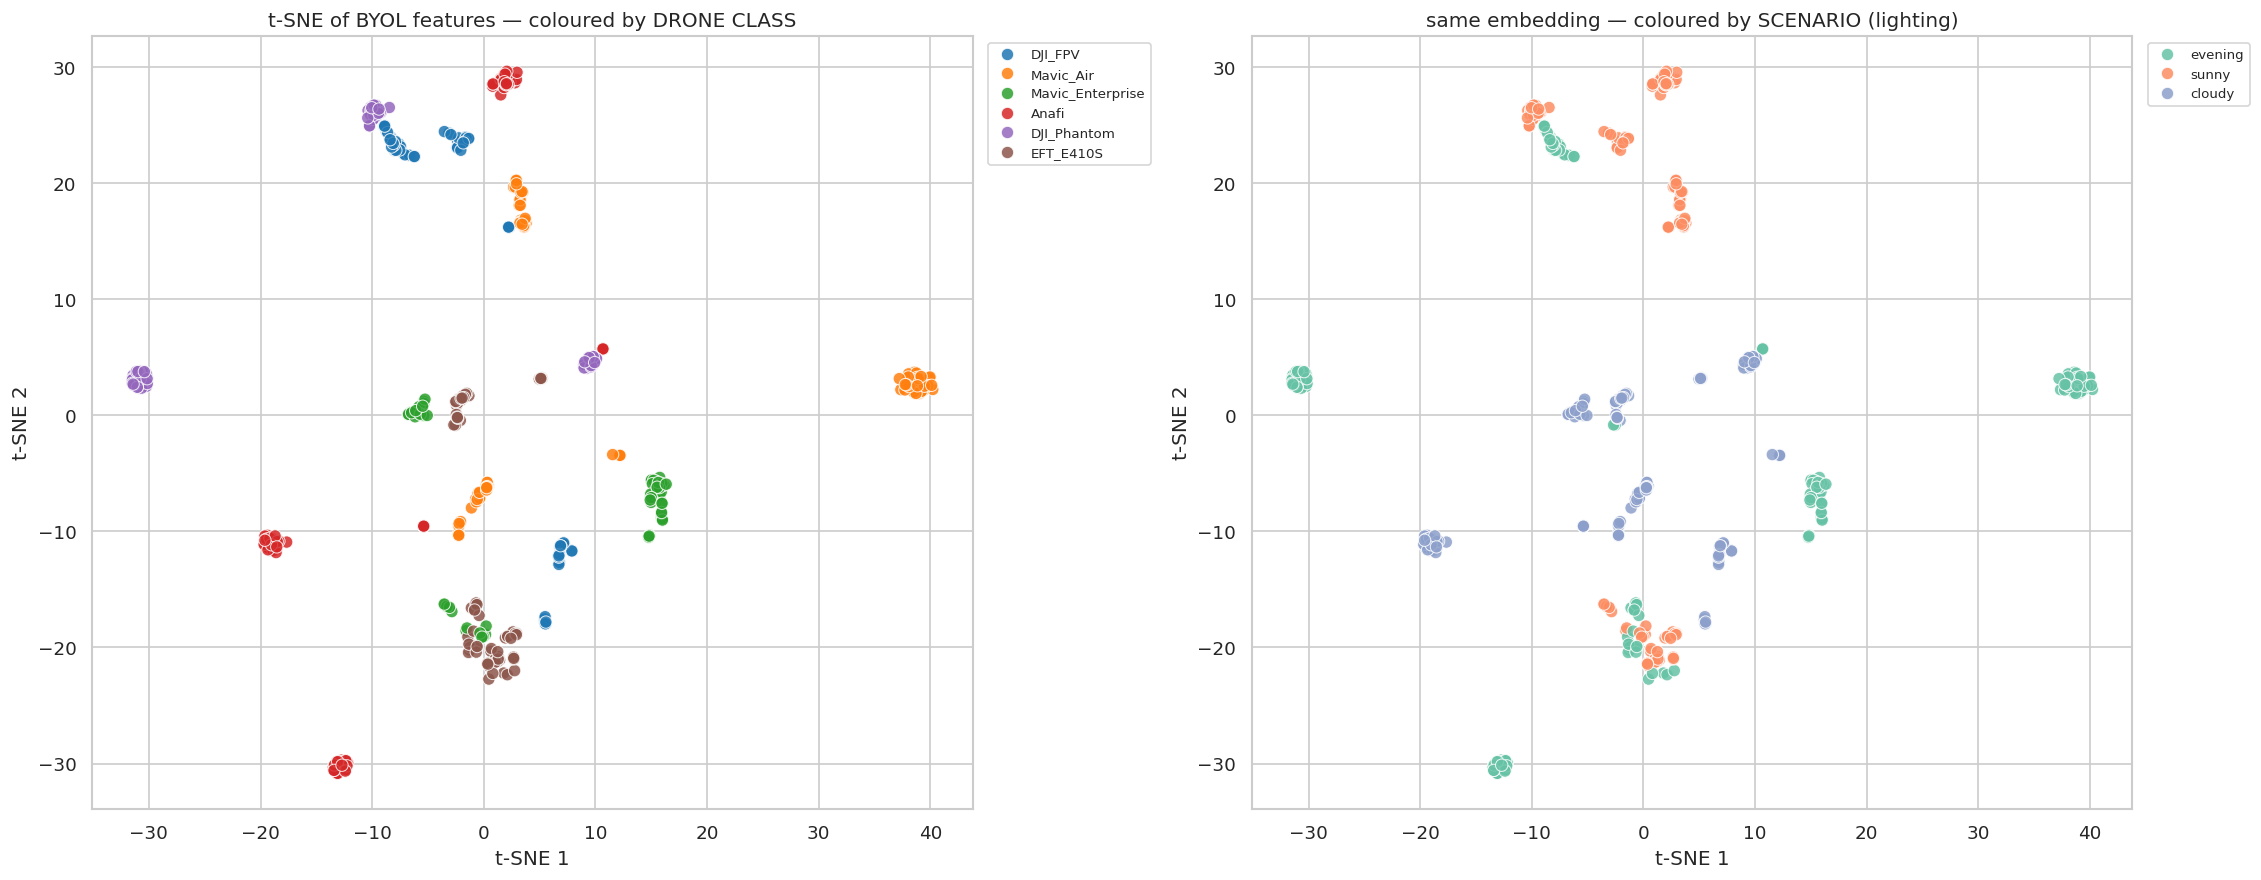

top-5 neighbour agreement — class: 98.7% (chance ~16.7%) | scenario: 97.9% (chance ~33.3%)


In [13]:
# ---- t-SNE coloured by class AND by scenario --------------------------------
perp = min(30.0, max(2.0, (len(feature_matrix) - 1) / 3))
coords = TSNE(n_components=2, perplexity=perp, learning_rate="auto",
              init="pca", max_iter=1000, random_state=PARTB_SEED
              ).fit_transform(feature_matrix.numpy())
frame = pd.DataFrame({"t-SNE 1": coords[:, 0], "t-SNE 2": coords[:, 1],
                      "class": sel_class, "scenario": sel_scen})
fig, axes = plt.subplots(1, 2, figsize=(19, 7.5))
sns.scatterplot(data=frame, x="t-SNE 1", y="t-SNE 2", hue="class",
                palette="tab10", s=55, alpha=0.85, ax=axes[0])
axes[0].set_title("t-SNE of BYOL features — coloured by DRONE CLASS")
sns.scatterplot(data=frame, x="t-SNE 1", y="t-SNE 2", hue="scenario",
                palette="Set2", s=55, alpha=0.85, ax=axes[1])
axes[1].set_title("same embedding — coloured by SCENARIO (lighting)")
for ax in axes:
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(f"{WORK_ROOT}/byol_tsne.png", dpi=150, bbox_inches="tight")
plt.show()

# quantitative check: do top-5 neighbours share the query's class?
sims = feature_matrix @ feature_matrix.T
sims.fill_diagonal_(-1)
top5 = sims.topk(5, dim=1).indices
agree = np.mean([[sel_class[j] == sel_class[i] for j in row.tolist()]
                 for i, row in enumerate(top5)])
scen_agree = np.mean([[sel_scen[j] == sel_scen[i] for j in row.tolist()]
                      for i, row in enumerate(top5)])
print(f"top-5 neighbour agreement — class: {agree:.1%} (chance ~16.7%) | "
      f"scenario: {scen_agree:.1%} (chance ~33.3%)")


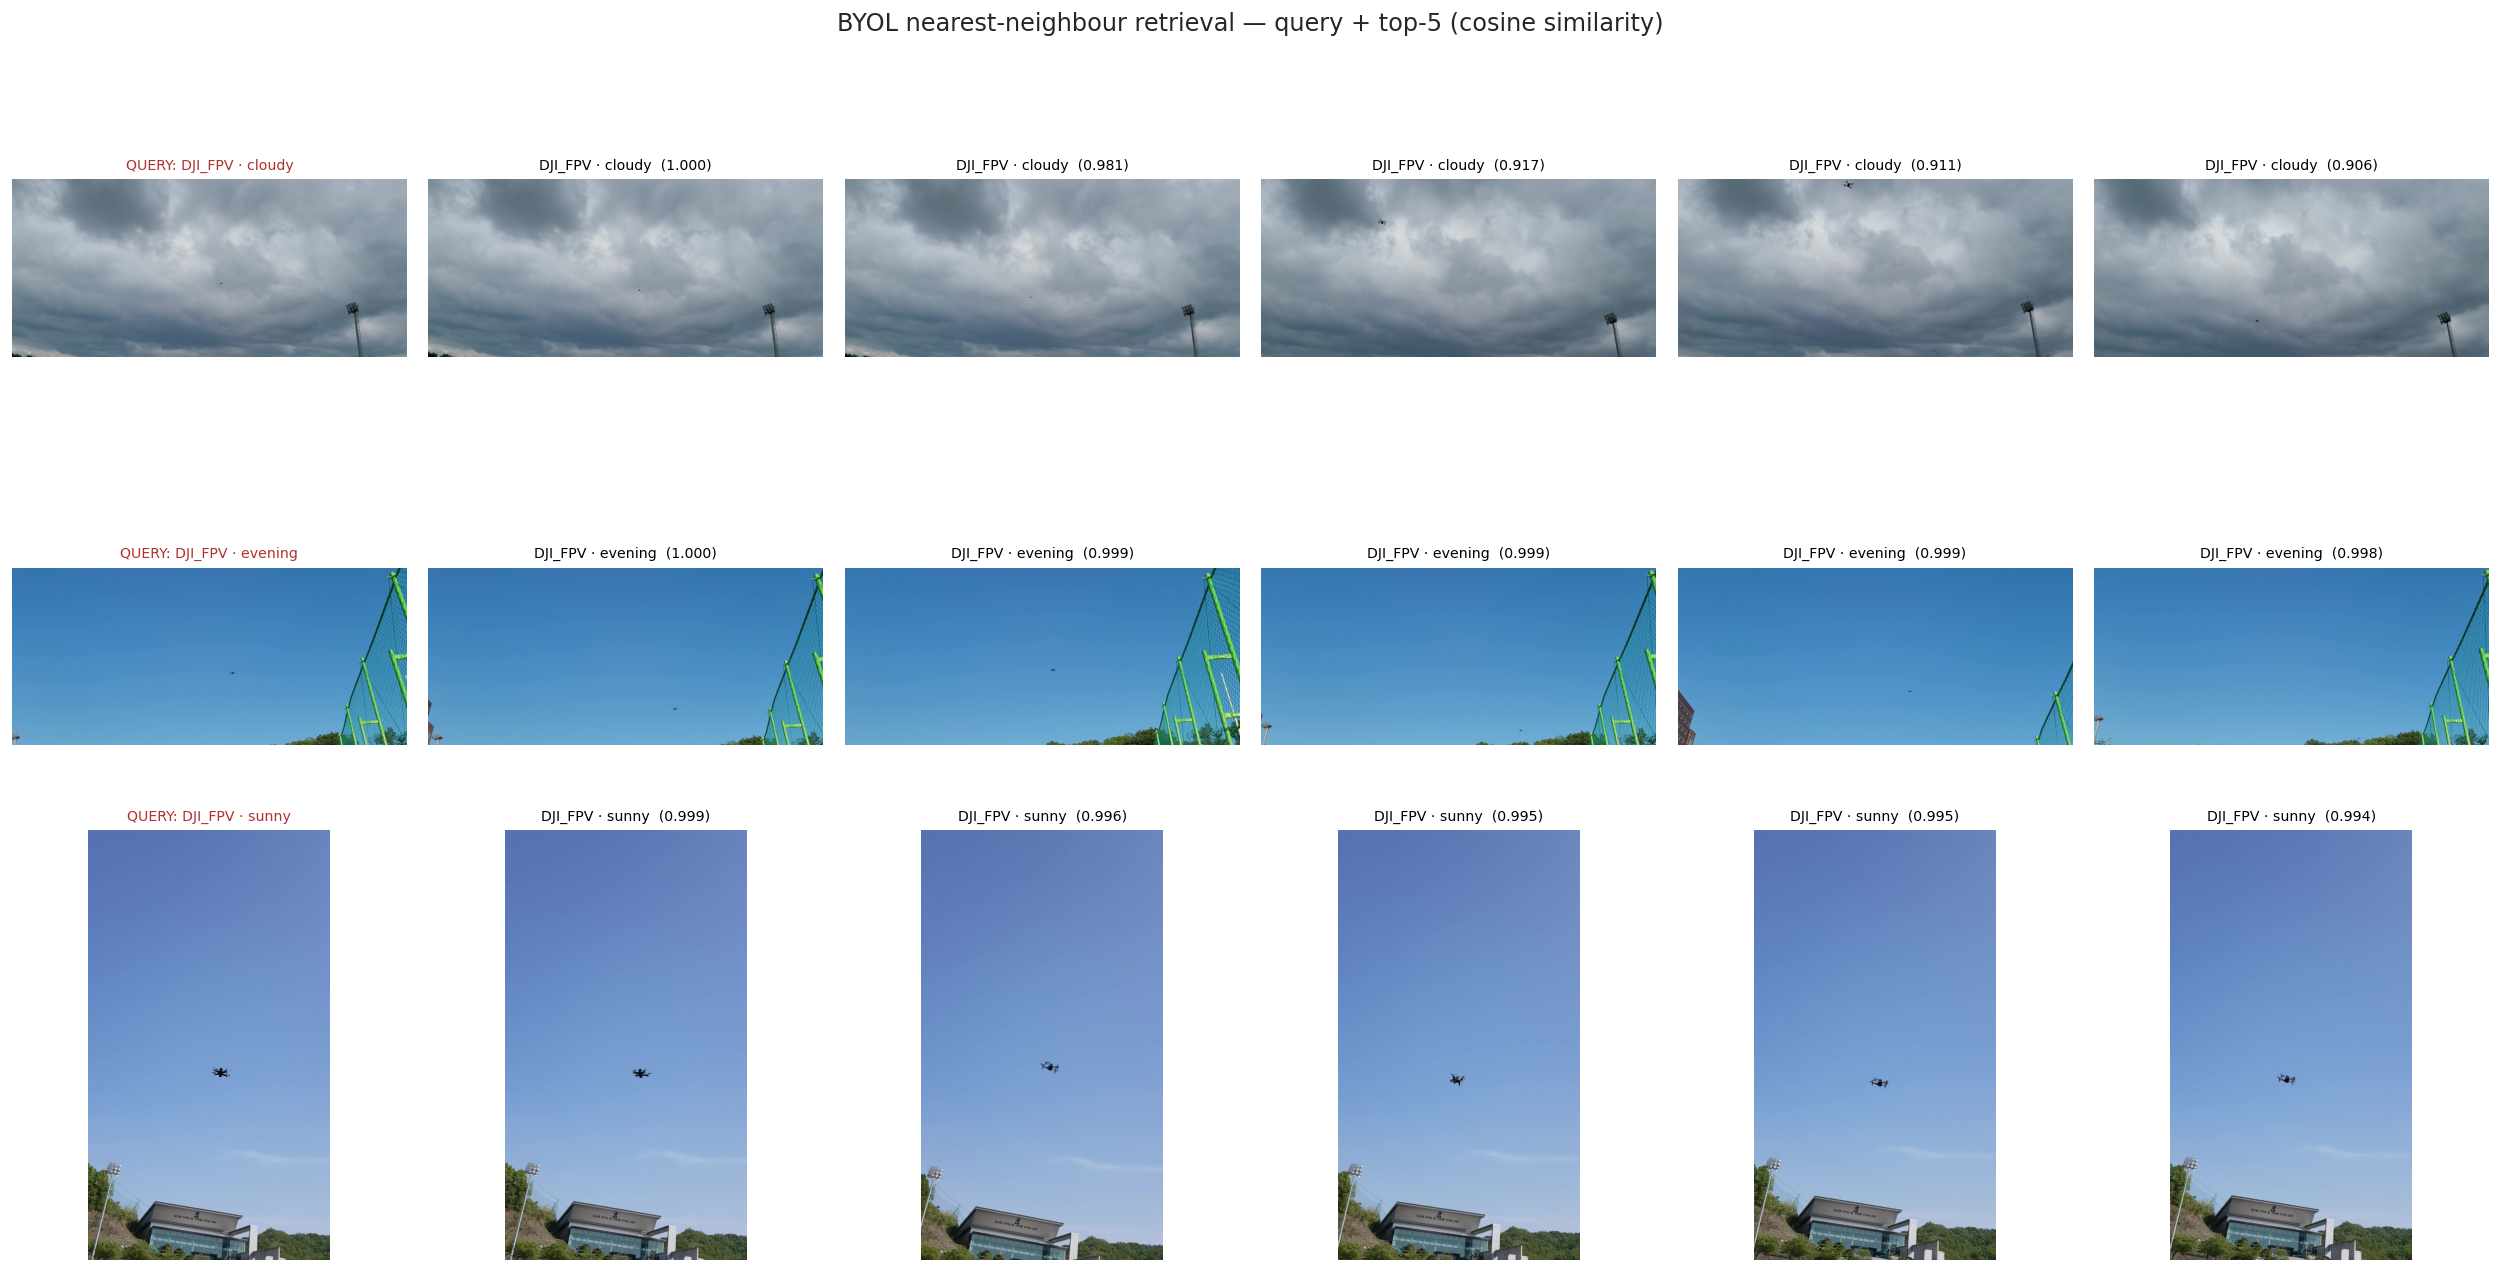

In [14]:
# ---- nearest-neighbour retrieval panels (one query per scenario) ------------
queries = [i for scen in SCENARIOS
           for i in [next((k for k, s in enumerate(sel_scen) if s == scen), None)]
           if i is not None] or [0]
fig, axes = plt.subplots(len(queries), 6, figsize=(21, 3.6 * len(queries)))
axes = np.atleast_2d(axes)
for row, q in enumerate(queries):
    nn = [j for j in sims[q].topk(6).indices.tolist() if j != q][:5]
    for col, idx in enumerate([q] + nn):
        ax = axes[row, col]
        with Image.open(sel_paths[idx]) as im:
            ax.imshow(im.convert("RGB"))
        ax.axis("off")
        ax.set_title("QUERY: " + f"{sel_class[idx]} · {sel_scen[idx]}" if col == 0
                     else f"{sel_class[idx]} · {sel_scen[idx]}  ({sims[q][idx]:.3f})",
                     fontsize=8.5, color="#b03030" if col == 0 else "black")
plt.suptitle("BYOL nearest-neighbour retrieval — query + top-5 (cosine similarity)")
plt.tight_layout()
plt.savefig(f"{WORK_ROOT}/byol_retrieval.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Checkpoint Export + Kaggle Dataset Hand-off 
| File in `/kaggle/working/` | Purpose |
|---|---|
| **`byol_backbone.pt`** | §7-convention SSL checkpoint (copy of `best_ssl.pt`) |
| **`byol_yolo26s_backbone.pt`** | YOLO-format backbone — what Notebook 2b actually loads |
| `partB_partition.csv` | The shared 10/10/80 partition + nested pool ranks — 3b and every other Part B notebook must consume THIS file |
| `byol_loss_curve.png`, `byol_tsne.png`, `byol_retrieval.png` | Report figures |
| `byol_yolo26s_visiodect/` | Full run dir: config yaml, history.csv, run_manifest.json, checkpoints |

**After committing:** create a public Kaggle dataset (e.g. `groupXX-partb-ssl-checkpoints`)
from this output; Notebook 2b attaches it and loads
`/kaggle/input/groupXX-partb-ssl-checkpoints/byol_yolo26s_backbone.pt`. Never write to
`/kaggle/input/` — it is read-only.

In [15]:
shutil.copy2(BEST_SSL, CKPT_BACKBONE)
shutil.copy2(YOLO_CHECKPOINT, CKPT_YOLO)
summary = {
    "method": SSL_METHOD, "encoder": "YOLOv26-s backbone (random init)",
    "epochs": EPOCHS, "image_size": IMAGE_SIZE,
    "effective_batch": BATCH_SIZE * GRAD_ACCUM * GPU_COUNT,
    "seed": PARTB_SEED, "ssl_pool_images": len(pool_images),
    "best_loss": manifest["best_loss"], "train_minutes": round(TRAIN_MINUTES, 1),
    "checkpoint_backbone": CKPT_BACKBONE, "checkpoint_yolo": CKPT_YOLO,
    "partition_manifest": PARTITION_CSV,
}
Path(f"{WORK_ROOT}/byol_pretrain_summary.json").write_text(json.dumps(summary, indent=2))
print(json.dumps(summary, indent=2))
for f in [CKPT_BACKBONE, CKPT_YOLO, PARTITION_CSV]:
    q = Path(f)
    print(f"[OK] {q.name:<30} {q.stat().st_size/1e6:>8.1f} MB" if q.exists() else f"MISSING {f}")


{
  "method": "byol",
  "encoder": "YOLOv26-s backbone (random init)",
  "epochs": 50,
  "image_size": 224,
  "effective_batch": 64,
  "seed": 445,
  "ssl_pool_images": 16483,
  "best_loss": 0.024137775527620777,
  "train_minutes": 250.6,
  "checkpoint_backbone": "/kaggle/working/byol_backbone.pt",
  "checkpoint_yolo": "/kaggle/working/byol_yolo26s_backbone.pt",
  "partition_manifest": "/kaggle/working/partB_partition.csv"
}
[OK] byol_backbone.pt                   94.4 MB
[OK] byol_yolo26s_backbone.pt           20.4 MB
[OK] partB_partition.csv                 4.6 MB


## 10. Pre-Commit Checklist 
- [ ] Install cell printed **ssl-detection-lab version >= 0.8.1** (restart + rerun if not)
- [ ] Partition sizes printed; disjointness `[OK]` (manifest diffable against 3a/4a)
- [ ] Two-view demo, dry-run loss, probe estimate, **50-epoch loss + momentum curves** visible
- [ ] Trainer image count matched the verified pool (`[OK]` assertion)
- [ ] t-SNE (class + scenario), retrieval panels, agreement %, per-dim feature std visible; §8.1 written
- [ ] `byol_backbone.pt`, `byol_yolo26s_backbone.pt`, `partB_partition.csv` printed `[OK]`
- [ ] Committed Public; files added to `groupXX-partb-ssl-checkpoints` (new version) for 2b

